# Imports and utils

In [1]:
import pandas as pd
import numpy as np
import ast
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

In [2]:
if 'google.colab' in str(get_ipython()): # running in colab
    !git clone --config lfs.fetchinclude="*"  https://github.com/sinc-lab/xvalRNAfolding.git
    DATA_PATH = './xvalRNAfolding/'
else:
    DATA_PATH = '/DATA/ncRNA/xval/'

In [3]:
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.minor.width'] = 0.4
plt.rcParams['ytick.minor.width'] = 0.4
plt.rcParams['xtick.major.size'] = 2.5
plt.rcParams['ytick.major.size'] = 2.5

In [4]:
strip_colors = sns.color_palette("tab10") # n_colors=Nfolds just remove the last 10-Nfolds colors
nshift = 8
strip_colors = strip_colors[nshift:] + strip_colors[:nshift]

In [ ]:
def subtract_one(list_of_lists):
  return [[element - 1 for element in sublist] for sublist in list_of_lists]

def generate_stats(id_list, data_df, max_length):
    count_GC = np.zeros((max_length,1))
    count_AU = np.zeros((max_length,1))
    count_GU = np.zeros((max_length,1))
    for _id in tqdm(id_list):
        pattern = data_df.loc[_id]
        if not (pattern['len'] <= max_length):
            continue
        connections = ast.literal_eval(pattern['base_pairs'])  # Convert string to list of lists
        connections = subtract_one(connections)  # Convert to 0-indexed
        seq = pattern['sequence']

        for k in range(len(connections)):
            if (seq[connections[k][0]] == 'G' and seq[connections[k][1]] == 'C') or \
                (seq[connections[k][0]] == 'C' and seq[connections[k][1]] == 'G'):
                dif = abs(connections[k][0] - connections[k][1])
                count_GC[dif,0] += 1
            if (seq[connections[k][0]] == 'A' and seq[connections[k][1]] == 'U') or \
                (seq[connections[k][0]] == 'U' and seq[connections[k][1]] == 'A'):
                dif = abs(connections[k][1] - connections[k][0])
                count_AU[dif,0] += 1
            if (seq[connections[k][0]] == 'G' and seq[connections[k][1]] == 'U') or \
                (seq[connections[k][0]] == 'U' and seq[connections[k][1]] == 'G'):
                dif = abs(connections[k][1] - connections[k][0])
                count_GU[dif,0] += 1

    return count_GC, count_AU, count_GU

def normalize_data(count_GU, count_AU, count_GC):
  total_connections = count_GU + count_AU + count_GC
  total_val = sum(total_connections) #total_connections.max()

  norm_GU = count_GU / total_val
  norm_AU = count_AU / total_val
  norm_GC = count_GC / total_val
  norm_total = (count_GU + count_AU + count_GC) / total_val

  return norm_GU, norm_AU, norm_GC, norm_total


def smooth_data(count_GU, count_AU, count_GC, max_length):
  gu_np = count_GU.squeeze()
  au_np = count_AU.squeeze()
  gc_np = count_GC.squeeze()

  window_length = 11
  polyorder = 3

  data_len = max_length
  if data_len < window_length:
      window_length = data_len if data_len % 2 == 1 else data_len - 1
      if window_length < 3: # Minimum window length for meaningful filter
          window_length = 3
      if polyorder >= window_length:
          polyorder = window_length - 1 if window_length > 1 else 0

  smoothed_GU = savgol_filter(gu_np, window_length, polyorder)
  smoothed_AU = savgol_filter(au_np, window_length, polyorder)
  smoothed_GC = savgol_filter(gc_np, window_length, polyorder)
  total_smoothed = smoothed_GU + smoothed_AU + smoothed_GC

  return smoothed_GU, smoothed_AU, smoothed_GC, total_smoothed

In [6]:
def plot_dist_smooth(count_GU_train, count_AU_train, count_GC_train, 
                     count_GU_test, count_AU_test, count_GC_test, 
                     max_length,
                     fig_width, fig_height, text_shift):

        
  font_size = 6 # max 7

  fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=150)
  plt.rcParams.update({'font.size': font_size})
  plt.xticks(fontsize=font_size)
  plt.yticks(fontsize=font_size)

  linew = 0.8
  train_gray = '#636363'
  test_palette = sns.light_palette(strip_colors[2], n_colors=4)[1:]  # light to dark from 3rd strip color
  #test_color = strip_colors[2]  # 3rd color from strip_colors
  test_color = test_palette[1]

  norm_GUtn, norm_AUtn, norm_GCtn, norm_total_train = normalize_data(count_GU_train, count_AU_train, count_GC_train)
  norm_GUts, norm_AUts, norm_GCts, norm_total_test = normalize_data(count_GU_test, count_AU_test, count_GC_test)
  norm_GUtn, norm_AUtn, norm_GCtn, norm_total_train = smooth_data(norm_GUtn, norm_AUtn, norm_GCtn, max_length)
  norm_GUts, norm_AUts, norm_GCts, norm_total_test = smooth_data(norm_GUts, norm_AUts, norm_GCts, max_length)

  max_val = max(norm_total_train.max(), norm_total_test.max())

  plt.plot(norm_total_train, label='Total train connections', color=train_gray, linewidth=linew)
  plt.plot(norm_total_test, label='Total test connections', color=test_color, linewidth=linew)

  plt.ylim(0, max_val * 1.05)

  txt = fig.text(
    text_shift, 0.01, "Connection distance",
    fontsize=5, ha="left", va="bottom" )
  txt.set_in_layout(False)

  plt.xticks([])
  plt.yticks([])
  for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
  plt.legend(loc='upper left',
             bbox_to_anchor=(0.15, 0.95),
             ncol=1, fontsize=5, frameon=False) # fontsize=5 as in test-to-train distributions
  plt.tight_layout()


def plot_histograms(count_GU_train, count_AU_train, count_GC_train, 
                    count_GU_test, count_AU_test, count_GC_test,
                    fig_width, fig_height):

  
  font_size = 6 # max 7

  fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=150)
  plt.rcParams.update({'font.size': font_size})
  plt.xticks(fontsize=font_size)
  plt.yticks(fontsize=font_size)

  train_palette = ['#d9d9d9', '#969696', '#525252']  # light to dark grays
  test_palette = sns.light_palette(strip_colors[2], n_colors=4)[1:]  # light to dark from 3rd strip color

  sum_train = sum(count_GU_train) + sum(count_AU_train) + sum(count_GC_train)
  sum_test  = sum(count_GU_test) + sum(count_AU_test) + sum(count_GC_test)
  # normalize to equalize the total area under the train and test histograms, so they can be compared on the same scale
  count_GU_train = count_GU_train / sum_train
  count_AU_train = count_AU_train / sum_train
  count_GC_train = count_GC_train / sum_train
  count_GU_test = count_GU_test / sum_test
  count_AU_test = count_AU_test / sum_test
  count_GC_test = count_GC_test / sum_test

  # compute histograms of the three connection types for train and test
  bins = np.linspace(0, len(count_GU_train), 11)
  centres = 0.5*(bins[:-1] + bins[1:])

  hist_GUtn, _ = np.histogram(np.arange(len(count_GU_train)),
                              bins=bins,
                              weights=count_GU_train.flatten())
  hist_AUtn, _ = np.histogram(np.arange(len(count_AU_train)),
                              bins=bins,
                              weights=count_AU_train.flatten())
  hist_GCtn, _ = np.histogram(np.arange(len(count_GC_train)),
                              bins=bins,
                              weights=count_GC_train.flatten())
  hist_GUts, _ = np.histogram(np.arange(len(count_GU_test)),
                              bins=bins,
                              weights=count_GU_test.flatten())
  hist_AUts, _ = np.histogram(np.arange(len(count_AU_test)),
                              bins=bins,
                              weights=count_AU_test.flatten())
  hist_GCts, _ = np.histogram(np.arange(len(count_GC_test)),
                              bins=bins,
                              weights=count_GC_test.flatten())

  # bar width and offsets
  bin_width = bins[1] - bins[0]
  bar_width = bin_width * 0.15
  offset = bar_width * 0.7

  # train positions (right side)
  x_gu_tn = centres + offset
  x_au_tn = centres + offset + bar_width
  x_gc_tn = centres + offset + 2 * bar_width

  # test positions (left side)
  x_gu_ts = centres - offset - 2 * bar_width
  x_au_ts = centres - offset - bar_width
  x_gc_ts = centres - offset

  plt.bar(x_gu_tn, hist_GUtn,
          width=bar_width, color=train_palette[0], label='GU train')
  plt.bar(x_au_tn, hist_AUtn,
          width=bar_width, color=train_palette[1], label='AU train')
  plt.bar(x_gc_tn, hist_GCtn,
          width=bar_width, color=train_palette[2], label='GC train')

  plt.bar(x_gu_ts, hist_GUts,
          width=bar_width, color=test_palette[0], label='GU test')
  plt.bar(x_au_ts, hist_AUts,
          width=bar_width, color=test_palette[1], label='AU test')
  plt.bar(x_gc_ts, hist_GCts,
          width=bar_width, color=test_palette[2], label='GC test')

  plt.xticks([0, 100, 200, 300, 400])#, 500])

  max_val = max(hist_GUtn.max(), hist_AUtn.max(), hist_GCtn.max(),
                hist_GUts.max(), hist_AUts.max(), hist_GCts.max())
  plt.ylim(0, max_val * 1.05)

  #plt.title(title, fontsize=font_size)
  plt.xlabel('Connection distance', fontsize=font_size)
  plt.xticks([0, 100, 200, 300, 400])#, 500])
  plt.yticks([])
  plt.legend(title=r"$\mathbf{tmRNA}$ fold base pairs", #r"$\mathbf{tmRNA}\\$Connections",
             loc='upper left',
             bbox_to_anchor=(0.15, 0.95),
             fontsize=5, # as in test-to-train distributions
             frameon=False,
             ncol=1)
     #ncol=1, fontsize=font_size, frameon=False)


# Data

In [8]:
data_df = pd.read_csv(DATA_PATH+"data/archiveII.csv", index_col="id")
fam = pd.read_csv(DATA_PATH+"data/fam_folds_split.csv")
# 0:grp1 1:tmRNA 2:tRNA 3:5s 4:srp 5:telomerase 6:RNaseP 7:16s 8:23s
max_length = 400

# FOLD 1: tmRNA

In [9]:
fold_number = 1
fold_data = fam[fam['fold_number'] == fold_number]
id_train = fold_data[fold_data['partition'] == 'train']['id'].tolist()
id_test = fold_data[fold_data['partition'] == 'test']['id'].tolist()
count_GC_train, count_AU_train, count_GU_train = generate_stats(id_train, data_df, max_length)
count_GC_test, count_AU_test, count_GU_test = generate_stats(id_test, data_df, max_length)

100%|██████████| 462/462 [00:00<00:00, 3580.13it/s]


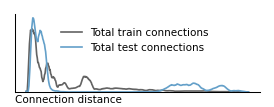

In [10]:
fig_width1col = 6.75/3*2*1.1 * 47/111 *42.01/48.63 # fam-fold strips scales to fill the remaining space in the 2col layout 
fig_height = 6.75/2/4 * 14.20/17.14 # same as test-to-train distributions

plot_dist_smooth(count_GU_train, count_AU_train, count_GC_train, count_GU_test, count_AU_test, count_GC_test, max_length=max_length,
                 fig_width=fig_width1col, fig_height=fig_height, text_shift=0.05)

plt.savefig(DATA_PATH + "figures/Fig_connections_smoothed_tmRNA.pdf", bbox_inches='tight', dpi=300)
plt.savefig(DATA_PATH + "figures/Fig_connections_smoothed_tmRNA.png", bbox_inches='tight', dpi=300)

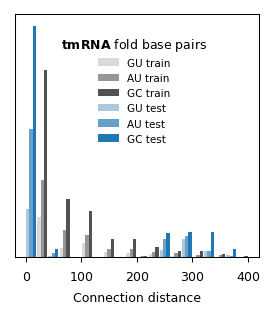

In [11]:
fig_width1col = 6.75/3*2*1.1 * 47/111 # fam-fold strips scales to fill the remaining space in the 2col layout 
fig_height = 2.0 * 40/38 # same as fam-fold strips

plot_histograms(count_GU_train, count_AU_train, count_GC_train, count_GU_test, count_AU_test, count_GC_test,
                fig_width=fig_width1col, fig_height=fig_height)

plt.savefig(DATA_PATH + "figures/Fig_connections_hist_tmRNA.pdf", bbox_inches='tight', dpi=300)
plt.savefig(DATA_PATH + "figures/Fig_connections_hist_tmRNA.png", bbox_inches='tight', dpi=300)